# 02 · Exploratory Data Analysis & Hypotheses

**Project:** An early-warning system for essential-price shocks across income quintiles in Pakistan (DS4SG, CS/SDP 312/314)

**Narrative.** Pakistan's poorest households cannot absorb sudden jumps in the price of essentials. We ask whether
**price-shock weeks can be predicted ahead of time, separately for each consumption quintile**, from signals that are
known in advance: exchange-rate moves, recent price momentum, and the administered-price calendar. We also ask whether
such a forecast works **as well for the poor as for the rich**.

Why forecast each quintile separately? Because the **burden of inflation rotates**: food-driven shocks hit the poorest
hardest, while fuel, energy and currency shocks hit richer households harder. Each quintile's exposures differ, so one
national forecast would serve some groups worse than others.

This notebook covers Milestone 2, Sections 3 and 4:

| Rubric item | Section |
|---|---|
| 3.1 Univariate summary statistics; skew; resistant vs non-resistant | §1 |
| 3.2 Outlier diagnostics (Z-score and quartile rules; masking) | §2 |
| 3.3 Bivariate and multivariate exploration | §3 |
| 3.4 Publication-quality figures (Grammar of Graphics) | Figures E1–E5 (`reports/figures/`) |
| 4.1–4.2 Formal hypotheses and variable mapping | §4 |

**Inputs:** `data/processed/master_features.csv` (from `notebooks/01_data_preparation.ipynb`, then
`python src/features/build_features.py`) and `data/processed/items_weekly_panel.csv`.
**Definition used throughout:** a **shock week** is a week in which a group's SPI rises by **at least 1%** (decision F1).

In [1]:
# --- Setup -------------------------------------------------------------------
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import statsmodels.api as sm
from scipy import stats
from IPython.display import display

ROOT = Path.cwd()
while not (ROOT / "CLAUDE.md").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))
from utils.plot_style import apply_style, GROUP_COLORS, SERIES, INK, INK_SECONDARY, GRID

apply_style()
pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 160)

DATA, FIG_DIR, TABLE_DIR = ROOT / "data", ROOT / "reports" / "figures", ROOT / "reports" / "tables"
GROUPS = ["Q1", "Q2", "Q3", "Q4", "Q5", "Combined"]
SHOCK = 1.0  # % weekly rise that defines a shock week

df = pd.read_csv(DATA / "processed" / "master_features.csv", parse_dates=["week_end"])
items = pd.read_csv(DATA / "processed" / "items_weekly_panel.csv", parse_dates=["week_end"])
week = df[df["group"] == "Combined"].set_index("week_end")          # week-level variables
wow = df.pivot(index="week_end", columns="group", values="spi_wow_pct")[GROUPS]
yoy = df.pivot(index="week_end", columns="group", values="spi_yoy_pct")[GROUPS]


def caption(fig, text, y=-0.02):
    # Figure caption under the plot, in secondary ink (never the series colour).
    fig.text(0.01, y, text, ha="left", va="top", fontsize=9, color=INK_SECONDARY)


def hac_ols(y, X, lags=4):
    # OLS with Newey-West (HAC) standard errors: weekly data are autocorrelated, so ordinary
    # standard errors would be too small and p-values too optimistic.
    X = sm.add_constant(X)
    m = pd.concat([y, X], axis=1).dropna()
    return sm.OLS(m.iloc[:, 0], m.iloc[:, 1:]).fit(cov_type="HAC", cov_kwds={"maxlags": lags})

print(f"{len(df):,} rows = {df['week_end'].nunique()} weeks x {df['group'].nunique()} groups; "
      f"{week.index.min():%d %b %Y} to {week.index.max():%d %b %Y}")

2,220 rows = 370 weeks x 6 groups; 05 Sep 2019 to 01 Oct 2026


## 1. Univariate summary statistics (rubric §3.1)

Each statistic is paired with its **resistant** counterpart (Unit 05):
* **centre:** the mean is non-resistant (pulled by extreme weeks); the **median** is resistant;
* **spread:** the standard deviation is non-resistant; the **IQR** is resistant. For a normal distribution
  IQR / 1.349 equals the SD, so we report that "robust SD" to compare the two directly.

The first table covers the target (weekly SPI change) for each group. The second covers the week-level predictors.

In [2]:
def describe(x):
    x = x.dropna()
    q1, q3 = x.quantile([0.25, 0.75])
    rsd = (q3 - q1) / 1.349 if q3 > q1 else np.nan   # undefined when most weeks are exactly 0
    return pd.Series({
        "n": len(x), "mean": x.mean(), "median": x.median(), "SD": x.std(), "IQR": q3 - q1,
        "robust SD (IQR/1.349)": rsd, "SD / robust SD": x.std() / rsd,
        "skewness": x.skew(), "excess kurtosis": x.kurt(), "min": x.min(), "max": x.max(),
    })

target_summary = pd.DataFrame({g: describe(wow[g]) for g in GROUPS}).T
target_summary.index.name = "weekly SPI change (%)"
display(target_summary.round(3))
target_summary.to_csv(TABLE_DIR / "eda_summary_target.csv")

,n,mean,median,SD,IQR,robust SD (IQR/1.349),SD / robust SD,skewness,excess kurtosis,min,max
weekly SPI change (%),,,,,,,,,,,
Q1,369.0,0.284,0.176,1.078,0.995,0.738,1.461,0.178,18.119,-8.445,6.654
Q2,369.0,0.299,0.176,1.282,0.998,0.740,1.733,-0.239,33.980,-11.910,10.336
Q3,369.0,0.307,0.182,1.151,0.888,0.658,1.748,2.968,44.933,-8.016,12.795
Q4,369.0,0.301,0.184,1.024,0.846,0.627,1.633,2.559,30.756,-6.066,10.504
Q5,369.0,0.296,0.168,0.962,0.785,0.582,1.654,1.982,13.845,-4.075,8.070
Combined,369.0,0.302,0.178,1.093,0.852,0.631,1.731,1.293,26.212,-8.108,9.949


In [3]:
predictors = {
    "spi_yoy_pct": "SPI y/y inflation, Combined (%)",
    "fx_wow_pct": "PKR/USD weekly change (%)",
    "fx_chg_8w": "PKR/USD change over 8 weeks (%)",
    "policy_rate": "SBP policy rate (%)",
    "infl_staples_wow": "Staple food, weekly price change (%)",
    "infl_perishables_wow": "Perishable food, weekly price change (%)",
    "infl_utilities_wow": "Utility tariffs, weekly change (%)",
    "infl_motor_fuel_wow": "Petrol and diesel, weekly change (%)",
    "momentum_spikes_4w": "Momentum-item spikes in past 4 weeks (count)",
}
pred_summary = pd.DataFrame({v: describe(week[k]) for k, v in predictors.items()}).T
display(pred_summary.round(3))
pred_summary.to_csv(TABLE_DIR / "eda_summary_predictors.csv")

,n,mean,median,SD,IQR,robust SD (IQR/1.349),SD / robust SD,skewness,excess kurtosis,min,max
"SPI y/y inflation, Combined (%)",370.0,17.579,15.231,12.658,18.597,13.786,0.918,0.645,-0.390,-3.523,48.353
PKR/USD weekly change (%),369.0,0.156,0.010,1.308,0.465,0.345,3.791,3.589,34.298,-5.453,13.516
PKR/USD change over 8 weeks (%),362.0,1.249,0.051,4.019,2.649,1.964,2.046,2.063,6.837,-9.004,21.134
SBP policy rate (%),370.0,13.256,12.000,5.076,7.000,5.189,0.978,0.520,-0.945,7.000,22.000
"Staple food, weekly price change (%)",370.0,0.260,0.174,0.485,0.434,0.322,1.507,2.597,15.218,-1.653,3.884
"Perishable food, weekly price change (%)",370.0,0.596,0.353,4.031,5.332,3.952,1.020,0.204,0.070,-9.086,14.565
"Utility tariffs, weekly change (%)",370.0,0.723,0.000,7.609,0.000,NaN,NaN,5.452,62.494,-51.913,79.045
"Petrol and diesel, weekly change (%)",370.0,0.406,0.000,3.809,0.000,NaN,NaN,2.608,25.258,-19.746,33.875
Momentum-item spikes in past 4 weeks (count),367.0,1.967,2.000,1.543,2.000,1.483,1.041,0.956,1.225,0.000,8.000


**Reading the tables**

* **Typical week vs average week.** For every group the median weekly change (about 0.17–0.18%) sits well below the
  mean (about 0.28–0.31%). A few large jumps pull the mean up, so the *typical* week is calmer than the average.
* **Heavy tails.** The SD is about 1.5–1.75 times the robust SD, and excess kurtosis is far above 0. Most weeks move a
  little, and a handful move a lot. That handful is exactly the shock weeks we want to forecast. The resistant
  statistics describe normal weeks; the non-resistant ones are driven by the shocks.
* **Q5 is the calmest group by every measure** (lowest SD and IQR), yet its SD / robust SD ratio is high: a narrow
  core with rare large jumps, which matters for the outlier rules below.
* **Predictors:** utility tariffs and motor fuel are extremely skewed. Their IQR is 0, so the robust SD is undefined, because in most weeks they don't move at all; then they
  jump when a decision is announced, which is the signature of administered prices. Staple food moves a little almost
  every week, which is the "grind".

## 2. Outlier diagnostics (rubric §3.2)

Both course rules (Unit 05), each in a *mild* and a *regular* version:

| Rule | Mild outlier | Regular outlier |
|---|---|---|
| Quartile (resistant) | beyond Q1 − 1.5·IQR or Q3 + 1.5·IQR | beyond Q1 − 3·IQR or Q3 + 3·IQR |
| Mean/SD, Z-score (non-resistant) | \|z\| > 2 | \|z\| > 3 |

**Masking:** extreme values inflate the SD, which widens the Z-score fences, so some extreme weeks hide each other.
To show this, we recompute the Z-rule after removing the regular quartile-rule outliers from the SD calculation.

In [4]:
rows = {}
for g in GROUPS:
    x = wow[g].dropna()
    q1, q3 = x.quantile([0.25, 0.75]); iqr = q3 - q1
    z = (x - x.mean()) / x.std()
    core = x[(x >= q1 - 3 * iqr) & (x <= q3 + 3 * iqr)]             # without regular outliers
    z_core = (x - core.mean()) / core.std()
    rows[g] = {
        "mild (1.5 IQR)": ((x < q1 - 1.5 * iqr) | (x > q3 + 1.5 * iqr)).sum(),
        "regular (3 IQR)": ((x < q1 - 3 * iqr) | (x > q3 + 3 * iqr)).sum(),
        "mild (|z|>2)": (z.abs() > 2).sum(),
        "regular (|z|>3)": (z.abs() > 3).sum(),
        "SD, all weeks": x.std(),
        "SD, without regular outliers": core.std(),
        "|z|>3 after unmasking": (z_core.abs() > 3).sum(),
    }
outliers = pd.DataFrame(rows).T
display(outliers.round(3))
outliers.to_csv(TABLE_DIR / "eda_outliers.csv")

,mild (1.5 IQR),regular (3 IQR),mild (|z|>2),regular (|z|>3),"SD, all weeks","SD, without regular outliers",|z|>3 after unmasking
Q1,17.0,6.0,13.0,6.0,1.078,0.788,10.0
Q2,17.0,6.0,10.0,6.0,1.282,0.831,12.0
Q3,18.0,6.0,10.0,4.0,1.151,0.753,11.0
Q4,19.0,5.0,13.0,5.0,1.024,0.752,11.0
Q5,23.0,11.0,20.0,6.0,0.962,0.701,19.0
Combined,20.0,9.0,15.0,7.0,1.093,0.731,14.0


* **The two rules disagree, and the quartile rule flags more weeks** (e.g. 17 mild outliers for Q1 vs 13 by |z| > 2).
  The quartile fences are built from resistant statistics, so the extreme weeks cannot widen them.
* **Masking is substantial.** Without the extreme weeks, the SD falls by about 25–35%, and the number of |z| > 3 weeks
  rises: from 6 to 10 for Q1, and from 6 to 19 for Q5. The extremes inflate the SD (variance inflation) and so hide
  each other. Q5 is most affected, because it has the narrowest core.

**Are the outliers errors?** No. The table below lists the largest weekly moves of the Combined index, with the
component that drove each (from PBS's item impacts). Every one coincides with a large administered-price change (a gas or electricity tariff change, or a fuel-price revision) or a broad staple-food move. None looks like a data error.

In [5]:
def component(item_id, category):
    if item_id in ("electricity_q1", "gas_q1"): return "utility tariffs"
    if item_id in ("petrol", "diesel"): return "motor fuel"
    if item_id in ("lpg", "firewood"): return "market energy"
    if item_id in ("tomatoes", "onions", "potatoes", "chicken", "eggs", "bananas", "garlic"): return "perishables"
    return "staple food" if category == "food" else "non-food"

items["component"] = [component(i, c) for i, c in zip(items["item_id"], items["category"])]
top = wow["Combined"].abs().sort_values(ascending=False).head(10).index
rows = []
for t in top:
    w = items[items["week_end"] == t]
    by_comp = w.groupby("component")["impact_combined"].sum()
    lead = w.loc[w["impact_combined"].abs().idxmax()] if w["impact_combined"].notna().any() else None
    rows.append({"week_end": t.date(), "Combined w/w %": wow.loc[t, "Combined"], "Q1 w/w %": wow.loc[t, "Q1"],
                 "Q5 w/w %": wow.loc[t, "Q5"],
                 "main component": by_comp.abs().idxmax() if by_comp.notna().any() else "n/a (no impacts)",
                 "largest item": f"{lead['item_id']} ({lead['price_wow_pct']:+.0f}%)" if lead is not None else "n/a"})
extremes = pd.DataFrame(rows)
display(extremes.round(2))
extremes.to_csv(TABLE_DIR / "eda_extreme_weeks.csv", index=False)

,week_end,Combined w/w %,Q1 w/w %,Q5 w/w %,main component,largest item
0,2023-11-16,9.95,6.63,8.07,utility tariffs,gas_q1 (+480%)
1,2022-09-22,-8.11,-8.45,-4.08,utility tariffs,electricity_q1 (-64%)
2,2022-10-27,4.13,4.64,0.88,utility tariffs,electricity_q1 (+89%)
3,2025-07-24,4.07,3.98,3.03,utility tariffs,gas_q1 (+30%)
4,2023-07-27,3.73,2.49,3.87,utility tariffs,electricity_q1 (+21%)
5,2022-07-28,3.68,3.27,3.54,utility tariffs,electricity_q1 (+26%)
6,2022-06-30,3.63,3.79,3.00,utility tariffs,electricity_q1 (+28%)
7,2022-06-16,3.38,2.85,3.10,motor fuel,petrol (+11%)
8,2022-08-18,3.35,1.80,3.94,utility tariffs,electricity_q1 (+7%)
9,2023-02-16,2.89,2.45,2.94,staple food,petrol (+9%)


**Decision: keep all outliers.** They are genuine shocks, mostly utility-tariff and fuel decisions, and they are the
events the early-warning model must learn. Removing or capping them would delete the signal. Instead:
* summaries use resistant statistics alongside the classical ones (as above);
* inference uses HAC (Newey-West) standard errors and non-parametric tests;
* the classification target (shock ≥ 1%) is itself robust to how extreme a shock is.

**Figure E3** shows the distribution of weekly changes by group, with the shock threshold.

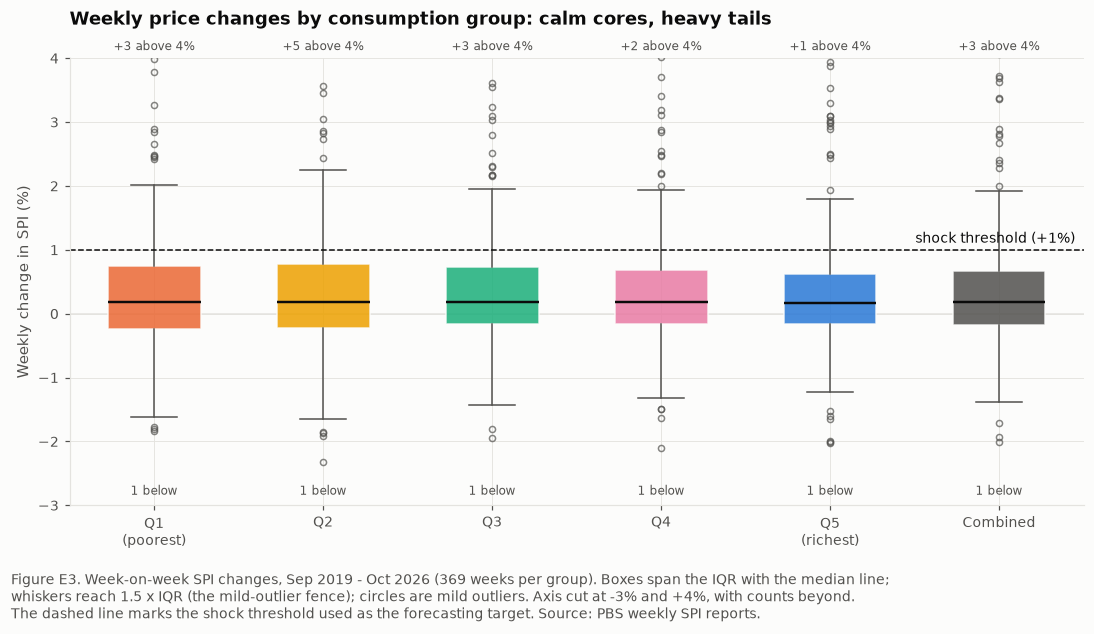

In [6]:
fig, ax = plt.subplots(figsize=(10, 5.2))
data = [wow[g].dropna() for g in GROUPS]
bp = ax.boxplot(data, orientation="vertical", patch_artist=True, widths=0.55, whis=1.5, showfliers=True,
                medianprops=dict(color=INK, linewidth=1.6),
                whiskerprops=dict(color=INK_SECONDARY, linewidth=1), capprops=dict(color=INK_SECONDARY),
                flierprops=dict(marker="o", markersize=4, markerfacecolor="none", markeredgecolor=INK_SECONDARY,
                                alpha=0.7))
for patch, g in zip(bp["boxes"], GROUPS):
    patch.set_facecolor(GROUP_COLORS[g]); patch.set_alpha(0.85); patch.set_edgecolor("#fcfcfb")
LO, HI = -3, 4
ax.set_ylim(LO, HI)
for i, x in enumerate(data, start=1):     # count of points beyond the visible range
    above, below = (x > HI).sum(), (x < LO).sum()
    if above: ax.text(i, HI + 0.08, f"+{above} above {HI}%", ha="center", va="bottom", fontsize=8,
                      color=INK_SECONDARY, clip_on=False)
    if below: ax.text(i, LO + 0.12, f"{below} below", ha="center", va="bottom", fontsize=8, color=INK_SECONDARY)
ax.axhline(SHOCK, color=INK, linestyle="--", linewidth=1)
ax.text(6.45, SHOCK + 0.06, "shock threshold (+1%)", ha="right", va="bottom", fontsize=9, color=INK)
ax.axhline(0, color=GRID, linewidth=1, zorder=0)
ax.set_xticks(range(1, 7), ["Q1\n(poorest)", "Q2", "Q3", "Q4", "Q5\n(richest)", "Combined"])
ax.set_ylabel("Weekly change in SPI (%)")
ax.set_title("Weekly price changes by consumption group: calm cores, heavy tails", pad=22)
caption(fig, "Figure E3. Week-on-week SPI changes, Sep 2019 - Oct 2026 (369 weeks per group). Boxes span the IQR with the median line;\nwhiskers reach 1.5 x IQR (the mild-outlier fence); circles are mild outliers. Axis cut at -3% and +4%, with counts beyond.\nThe dashed line marks the shock threshold used as the forecasting target. Source: PBS weekly SPI reports.", y=-0.01)
fig.tight_layout()
fig.savefig(FIG_DIR / "figE3_weekly_change_distribution.png")
plt.show()

## 3. Bivariate and multivariate exploration (rubric §3.3)

### 3.1 The rotating burden: who faces more inflation, and when?

The group-by tables compare cumulative inflation and the shock rate by quintile across three periods.

In [7]:
periods = {"2019-21": ("2019-09", "2021-12"), "2022-23": ("2022-01", "2023-12"), "2024-26": ("2024-01", "2026-12")}
lvl = df.pivot(index="week_end", columns="group", values="spi")[GROUPS]
cum = pd.DataFrame({k: (lvl.loc[a:b].iloc[-1] / lvl.loc[a:b].iloc[0] - 1) * 100
                    for k, (a, b) in periods.items()}).T
cum.loc["full sample"] = (lvl.iloc[-1] / lvl.iloc[0] - 1) * 100
print("Cumulative inflation (%) by period and group")
display(cum.round(1))

per = pd.cut(wow.index, [pd.Timestamp("2019-09-01"), pd.Timestamp("2021-12-31"), pd.Timestamp("2023-12-31"),
                         pd.Timestamp("2026-12-31")], labels=list(periods))
shock_rate = (wow >= SHOCK).groupby(per, observed=True).mean().mul(100)
shock_rate.loc["full sample"] = (wow >= SHOCK).mean().mul(100)
print("Share of weeks that were shock weeks (%)")
display(shock_rate.round(1))
cum.to_csv(TABLE_DIR / "eda_cumulative_inflation.csv"); shock_rate.to_csv(TABLE_DIR / "eda_shock_rate.csv")

Cumulative inflation (%) by period and group


group,Q1,Q2,Q3,Q4,Q5,Combined
2019-21,38.8,36.8,34.4,33.5,33.9,35.1
2022-23,74.0,80.8,91.5,89.5,83.1,85.1
2024-26,15.0,17.2,16.7,16.7,18.2,18.1
full sample,179.1,191.9,202.3,197.7,192.8,197.9


Share of weeks that were shock weeks (%)


group,Q1,Q2,Q3,Q4,Q5,Combined
2019-21,9.0,13.1,11.5,13.1,10.7,12.3
2022-23,26.9,28.8,25.0,27.9,24.0,25.0
2024-26,9.0,10.4,9.0,9.7,7.6,9.7
full sample,14.1,16.5,14.3,15.9,13.2,14.9


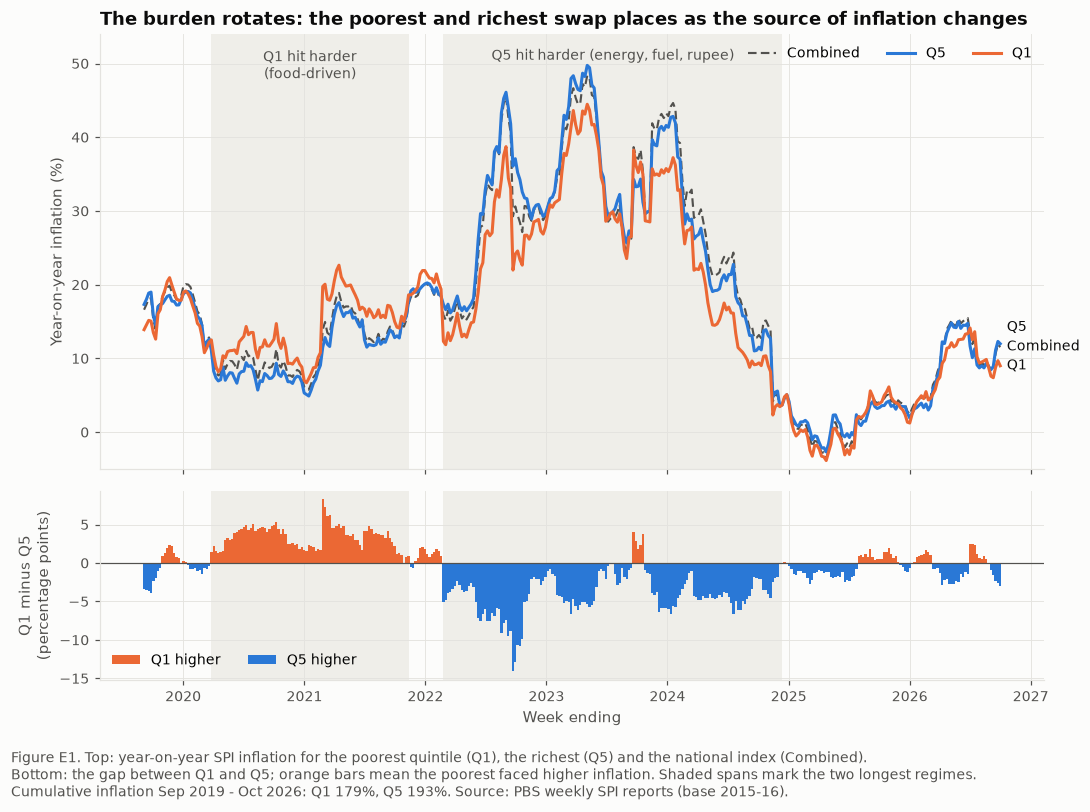

In [8]:
gap = (yoy["Q1"] - yoy["Q5"]).dropna()
fig, (ax, axg) = plt.subplots(2, 1, figsize=(10, 6.8), sharex=True, gridspec_kw={"height_ratios": [2.3, 1]})
regimes = [("2020-03-26", "2021-11-11", "Q1 hit harder\n(food-driven)"),
           ("2022-02-24", "2024-12-12", "Q5 hit harder (energy, fuel, rupee)")]
for a in (ax, axg):
    for s, e, _ in regimes:
        a.axvspan(pd.Timestamp(s), pd.Timestamp(e), color="#efeee9", zorder=0)
for s, e, lab in regimes:
    ax.text(pd.Timestamp(s) + (pd.Timestamp(e) - pd.Timestamp(s)) / 2, 52, lab, ha="center", va="top",
            fontsize=9, color=INK_SECONDARY)
for g, lw, ls in [("Combined", 1.4, (0, (4, 2))), ("Q5", 2, "-"), ("Q1", 2, "-")]:
    ax.plot(yoy.index, yoy[g], color=GROUP_COLORS[g], linewidth=lw, linestyle=ls, label=g)
# Direct labels at the line ends, pushed apart so they never overlap (min. 2.6 points apart).
ends = sorted([(yoy[g].iloc[-1], g) for g in ["Q1", "Q5", "Combined"]])
ypos = [ends[0][0]]
for v, _ in ends[1:]:
    ypos.append(max(v, ypos[-1] + 2.6))
for (v, g), yl in zip(ends, ypos):
    ax.text(yoy.index[-1] + pd.Timedelta(days=20), yl, g, color=INK, fontsize=9, va="center")
ax.set_ylabel("Year-on-year inflation (%)")
ax.set_ylim(-5, 54)
ax.legend(loc="upper right", ncol=3)
ax.set_title("The burden rotates: the poorest and richest swap places as the source of inflation changes")
axg.bar(gap.index, gap.where(gap > 0), width=7, color=GROUP_COLORS["Q1"], label="Q1 higher")
axg.bar(gap.index, gap.where(gap <= 0), width=7, color=GROUP_COLORS["Q5"], label="Q5 higher")
axg.axhline(0, color=INK_SECONDARY, linewidth=0.8)
axg.set_ylabel("Q1 minus Q5\n(percentage points)")
axg.set_xlabel("Week ending")
axg.legend(loc="lower left", ncol=2)
axg.xaxis.set_major_locator(mdates.YearLocator())
axg.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
caption(fig, "Figure E1. Top: year-on-year SPI inflation for the poorest quintile (Q1), the richest (Q5) and the national index (Combined).\nBottom: the gap between Q1 and Q5; orange bars mean the poorest faced higher inflation. Shaded spans mark the two longest regimes.\nCumulative inflation Sep 2019 - Oct 2026: Q1 179%, Q5 193%. Source: PBS weekly SPI reports (base 2015-16).", y=-0.01)
fig.tight_layout()
fig.savefig(FIG_DIR / "figE1_rotating_burden.png")
plt.show()

**What drives the rotation?** We estimate each quintile's **exposure** to six price components. Each weekly SPI change
is regressed on the weekly price change of each component (OLS, HAC errors). A coefficient of 10 means 10% of a 1%
component price rise shows up in that group's index. This recovers the basket differences that PBS does not publish
for Q2–Q5.

In [9]:
comps = {"infl_utilities_wow": "utility tariffs", "infl_motor_fuel_wow": "motor fuel",
         "infl_market_energy_wow": "LPG & firewood", "infl_perishables_wow": "perishables",
         "infl_staples_wow": "staple food", "infl_nonfood_wow": "non-food"}
X = week[list(comps)].rename(columns=comps)
expo = {}
for g in GROUPS:
    m = hac_ols(wow[g], X)
    expo[g] = {**(m.params.drop("const") * 100).to_dict(), "R²": m.rsquared}
exposure = pd.DataFrame(expo).T
display(exposure.round(2))
exposure.to_csv(TABLE_DIR / "eda_exposure_by_quintile.csv")

,utility tariffs,motor fuel,LPG & firewood,perishables,staple food,non-food,R²
Q1,10.20,2.66,2.43,12.40,45.07,11.14,0.80
Q2,13.21,4.23,2.82,12.25,40.96,8.54,0.81
Q3,11.31,4.99,3.20,11.24,47.66,5.95,0.79
Q4,9.02,6.69,3.57,11.15,46.05,8.22,0.78
Q5,6.92,10.73,6.36,9.52,33.25,16.48,0.76
Combined,10.36,8.41,4.97,10.46,34.95,11.01,0.82


A clear **gradient across income**:
* exposure to motor fuel rises steadily from Q1 to Q5;
* exposure to perishables and staple food is higher for Q1–Q4 than for Q5;
* exposure to utility tariffs peaks at Q2–Q3.

Together these components explain about 80% of weekly movement in every group. This is why a single national model
would misjudge shocks for some quintiles. It is the case for quintile-specific forecasts.

### 3.2 Shocks vs the grind: what moves prices week to week?

PBS's item impacts are available for Q1 and Combined. They show how each component contributes to the **level** of
inflation (cumulative) and to its **week-to-week variability** (the share of the weekly variance; the components'
covariances with the total sum to 100%).

In [10]:
order = ["utility tariffs", "motor fuel", "market energy", "perishables", "staple food", "non-food"]
last = items[items["week_end"] == items["week_end"].max()]
res = {}
for col, lab, wcol in (("impact_q1", "Q1", "weight_q1"), ("impact_combined", "Combined", "weight_combined")):
    c = items.pivot_table(index="week_end", columns="component", values=col, aggfunc="sum")[order].dropna()
    tot = c.sum(axis=1)
    res[(lab, "basket weight %")] = last.groupby("component")[wcol].sum().reindex(order)
    res[(lab, "cumulative pp")] = c.sum()
    res[(lab, "share of weekly variance %")] = c.apply(lambda x: np.cov(x, tot)[0, 1]) / tot.var() * 100
decomp = pd.DataFrame(res)
display(decomp.round(1))
decomp.to_csv(TABLE_DIR / "eda_shocks_vs_grind.csv")

Q1                                                 Combined                                         
                basket weight % cumulative pp share of weekly variance % basket weight % cumulative pp share of weekly variance %
component                                                                                                                        
utility tariffs            10.4          21.6                       60.6            16.0          27.7                       64.8
motor fuel                  1.5           2.2                        0.7             6.8          10.8                        9.4
market energy               5.7           4.1                        0.7             2.6           3.1                        1.7
perishables                11.9           9.7                       28.1            10.7           8.8                       16.8
staple food                57.0          53.0                        7.9            51.6          48.8                        5.7
non-food                   13.4          12.7                        1.9            12.2          11.0                        1.7

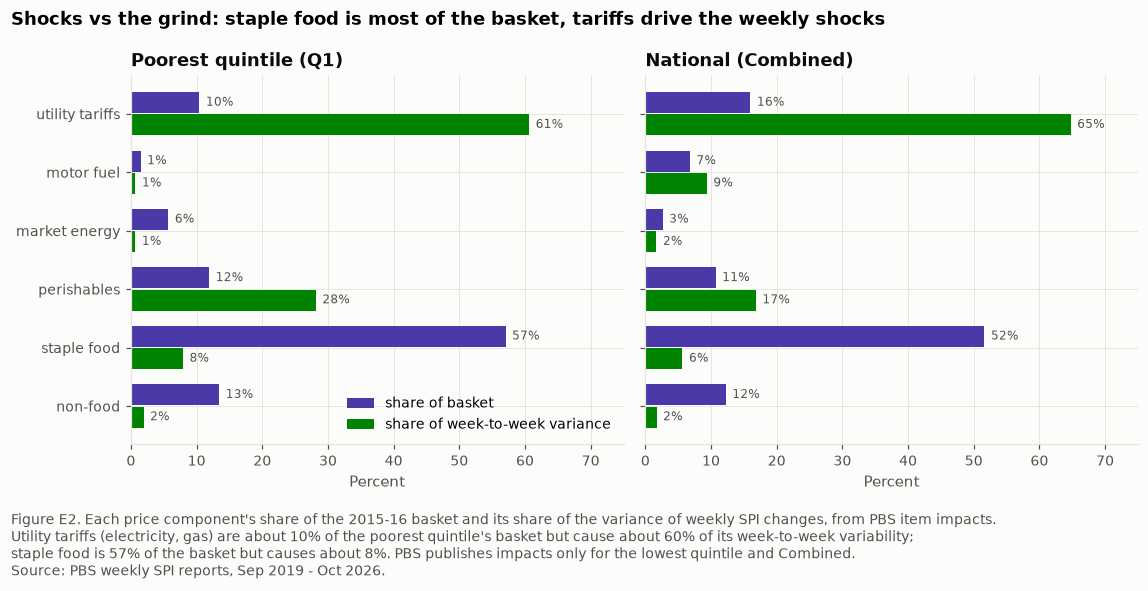

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.6), sharey=True)
y = np.arange(len(order))[::-1]
C_W, C_V = SERIES[6], SERIES[5]          # violet = basket weight, green = variance share
for ax, lab in zip(axes, ["Q1", "Combined"]):
    wv, vv = decomp[(lab, "basket weight %")].values, decomp[(lab, "share of weekly variance %")].values
    ax.barh(y + 0.19, wv, height=0.36, color=C_W, label="share of basket")
    ax.barh(y - 0.19, vv, height=0.36, color=C_V, label="share of week-to-week variance")
    for yi, a, b in zip(y, wv, vv):
        ax.text(a + 1, yi + 0.19, f"{a:.0f}%", va="center", fontsize=8, color=INK_SECONDARY)
        ax.text(max(b, 0) + 1, yi - 0.19, f"{b:.0f}%", va="center", fontsize=8, color=INK_SECONDARY)
    ax.set_title("Poorest quintile (Q1)" if lab == "Q1" else "National (Combined)")
    ax.set_xlim(0, 75)
    ax.set_xlabel("Percent")
axes[0].set_yticks(y, order)
axes[0].legend(loc="lower right")
fig.suptitle("Shocks vs the grind: staple food is most of the basket, tariffs drive the weekly shocks",
             x=0.01, ha="left", fontsize=12, fontweight="bold")
caption(fig, "Figure E2. Each price component's share of the 2015-16 basket and its share of the variance of weekly SPI changes, from PBS item impacts.\nUtility tariffs (electricity, gas) are about 10% of the poorest quintile's basket but cause about 60% of its week-to-week variability;\nstaple food is 57% of the basket but causes about 8%. PBS publishes impacts only for the lowest quintile and Combined.\nSource: PBS weekly SPI reports, Sep 2019 - Oct 2026.", y=-0.01)
fig.tight_layout()
fig.savefig(FIG_DIR / "figE2_shocks_vs_grind.png")
plt.show()

### 3.3 Early-warning signals: what raises the chance of a shock next week?

Contingency tables cross each candidate signal (known at the end of week *t*) with whether week *t+1* is a shock week,
for Q1, Q5 and Combined. Fisher's exact test checks independence; it suits small cells such as the 7 fiscal-year-start
weeks. Continuous signals are made binary with simple, pre-stated cut-offs:
* rupee depreciation of more than 2% over 8 weeks;
* at least one shock in the past 4 weeks;
* at least 2 momentum-item spikes in the past 4 weeks.

In [12]:
d = df[df["target_shock_next"].notna()].copy()
d["fx_depreciation_8w"] = (d["fx_chg_8w"] > 2).astype(int)
d["shock_in_last_4w"] = (d["shocks_last_4w"] >= 1).astype(int)
d["momentum_spikes"] = (d["momentum_spikes_4w"] >= 2).astype(int)
signals = {"fx_depreciation_8w": "Rupee fell >2% in past 8 weeks",
           "shock_in_last_4w": "Shock in past 4 weeks",
           "momentum_spikes": "Momentum-item spikes (>=2 in 4 weeks)",
           "fy_start_next_week": "Fiscal year starts next week",
           "fuel_review_next_week": "Fuel-price review next week",
           "pre_eid_adha_4w": "Eid ul-Adha within 4 weeks",
           "ramadan_next_week": "Ramadan next week"}
rows = []
for s, label in signals.items():
    for g in ["Q1", "Q5", "Combined"]:
        sub = d[d["group"] == g]
        tab = pd.crosstab(sub[s], sub["target_shock_next"])
        on, off = sub.loc[sub[s] == 1, "target_shock_next"], sub.loc[sub[s] == 0, "target_shock_next"]
        diff = on.mean() - off.mean()
        se = np.sqrt(on.mean() * (1 - on.mean()) / len(on) + off.mean() * (1 - off.mean()) / len(off))
        rows.append({"signal": label, "group": g, "weeks with signal": len(on),
                     "P(shock | signal) %": 100 * on.mean(), "P(shock | no signal) %": 100 * off.mean(),
                     "difference (pp)": 100 * diff, "95% CI low": 100 * (diff - 1.96 * se),
                     "95% CI high": 100 * (diff + 1.96 * se), "Fisher p": stats.fisher_exact(tab)[1]})
sig = pd.DataFrame(rows)
display(sig.round(3))
sig.to_csv(TABLE_DIR / "eda_signal_contingency.csv", index=False)

,signal,group,weeks with signal,P(shock | signal) %,P(shock | no signal) %,difference (pp),95% CI low,95% CI high,Fisher p
0,Rupee fell >2% in past 8 weeks,Q1,100,23.000,10.781,12.219,3.177,21.262,0.004
1,Rupee fell >2% in past 8 weeks,Q5,100,27.000,8.178,18.822,9.524,28.119,0.000
2,Rupee fell >2% in past 8 weeks,Combined,100,26.000,10.781,15.219,5.857,24.581,0.000
3,Shock in past 4 weeks,Q1,146,21.233,9.417,11.816,4.154,19.477,0.002
4,Shock in past 4 weeks,Q5,133,21.805,8.475,13.330,5.464,21.196,0.001
5,Shock in past 4 weeks,Combined,149,22.819,9.545,13.273,5.496,21.051,0.001
6,Momentum-item spikes (>=2 in 4 weeks),Q1,214,16.355,10.968,5.387,-1.595,12.370,0.173
7,Momentum-item spikes (>=2 in 4 weeks),Q5,214,16.355,9.032,7.323,0.620,14.025,0.044
8,Momentum-item spikes (>=2 in 4 weeks),Combined,214,18.224,10.323,7.902,0.852,14.951,0.039
9,Fiscal year starts next week,Q1,7,42.857,13.536,29.321,-7.508,66.151,0.061


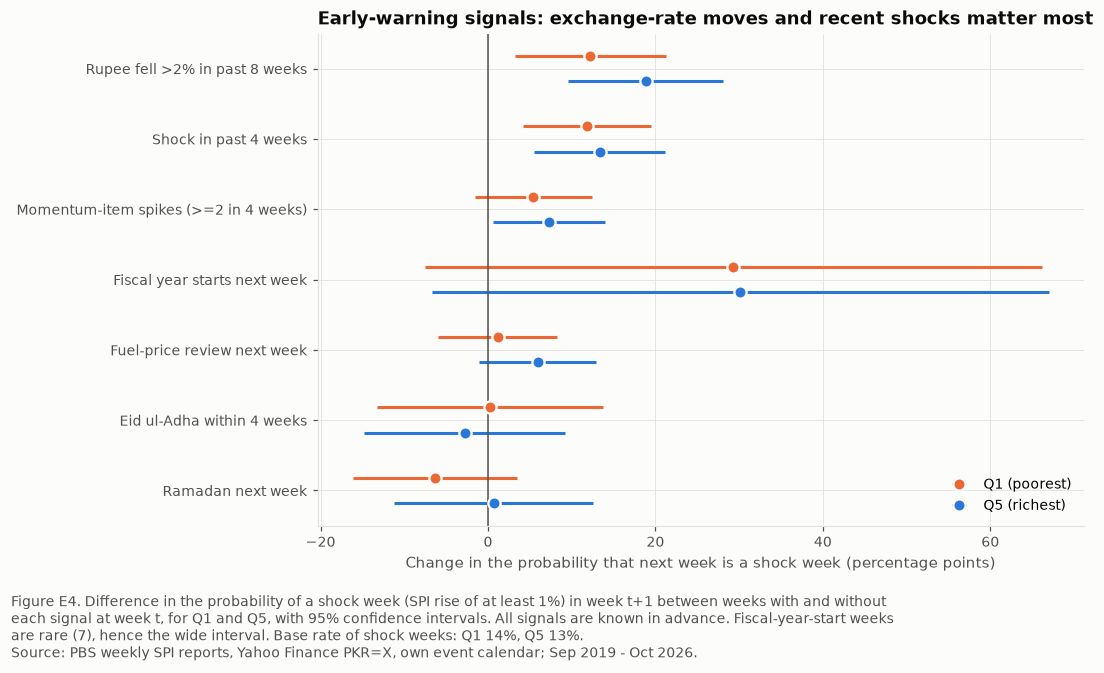

In [13]:
show = sig[sig["group"].isin(["Q1", "Q5"])].copy()
labels = list(signals.values())
fig, ax = plt.subplots(figsize=(10, 5.4))
ypos = np.arange(len(labels))[::-1]
for k, (g, off) in enumerate([("Q1", 0.18), ("Q5", -0.18)]):
    s = show[show["group"] == g].set_index("signal").loc[labels]
    ax.errorbar(s["difference (pp)"], ypos + off,
                xerr=[s["difference (pp)"] - s["95% CI low"], s["95% CI high"] - s["difference (pp)"]],
                fmt="o", markersize=8, color=GROUP_COLORS[g], ecolor=GROUP_COLORS[g], elinewidth=2, capsize=0,
                label=f"{g} ({'poorest' if g == 'Q1' else 'richest'})", markeredgecolor="#fcfcfb",
                markeredgewidth=1.5)
ax.axvline(0, color=INK_SECONDARY, linewidth=1)
ax.set_yticks(ypos, labels)
ax.set_xlabel("Change in the probability that next week is a shock week (percentage points)")
ax.set_title("Early-warning signals: exchange-rate moves and recent shocks matter most")
ax.legend(loc="lower right")
caption(fig, "Figure E4. Difference in the probability of a shock week (SPI rise of at least 1%) in week t+1 between weeks with and without\neach signal at week t, for Q1 and Q5, with 95% confidence intervals. All signals are known in advance. Fiscal-year-start weeks\nare rare (7), hence the wide interval. Base rate of shock weeks: Q1 14%, Q5 13%.\nSource: PBS weekly SPI reports, Yahoo Finance PKR=X, own event calendar; Sep 2019 - Oct 2026.", y=-0.01)
fig.tight_layout()
fig.savefig(FIG_DIR / "figE4_early_warning_signals.png")
plt.show()

### 3.4 Exchange-rate pass-through by quintile

How much of a 1% rupee depreciation in week *t* shows up in each group's SPI over the following *k* weeks? For each
horizon *k* = 1…13 we regress the cumulative SPI change over weeks *t* … *t+k−1* on the week-*t* change in PKR/USD (OLS,
HAC standard errors).

,Q1,Q5,Combined
horizon (weeks),,,
1,0.013,0.074,0.040
4,0.099,0.340,0.215
8,0.438,0.588,0.516
13,0.514,0.684,0.567


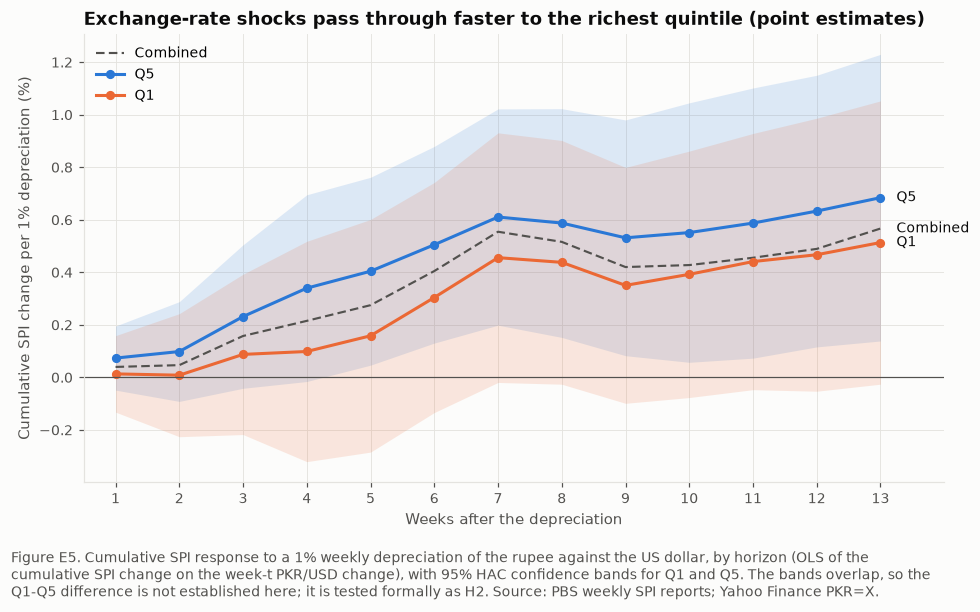

In [14]:
H = range(1, 14)
pt, lo, hi = {}, {}, {}
for g in ["Q1", "Q5", "Combined"]:
    pt[g], lo[g], hi[g] = [], [], []
    for k in H:
        y = wow[g].rolling(k).sum().shift(-k + 1).rename("y")
        m = hac_ols(y, week["fx_wow_pct"], lags=k + 2)
        b, se = m.params["fx_wow_pct"], m.bse["fx_wow_pct"]
        pt[g].append(b); lo[g].append(b - 1.96 * se); hi[g].append(b + 1.96 * se)
passthrough = pd.DataFrame(pt, index=pd.Index(H, name="horizon (weeks)"))
display(passthrough.loc[[1, 4, 8, 13]].round(3))
passthrough.to_csv(TABLE_DIR / "eda_fx_passthrough.csv")

fig, ax = plt.subplots(figsize=(9, 5))
for g in ["Q5", "Q1"]:
    ax.fill_between(list(H), lo[g], hi[g], color=GROUP_COLORS[g], alpha=0.15, linewidth=0)
for g, ls, lw in [("Combined", (0, (4, 2)), 1.4), ("Q5", "-", 2), ("Q1", "-", 2)]:
    ax.plot(list(H), pt[g], color=GROUP_COLORS[g], linestyle=ls, linewidth=lw, marker="o" if g != "Combined" else None,
            markersize=5, label=g)
    ax.text(13.25, pt[g][-1], g, va="center", fontsize=9, color=INK)
ax.axhline(0, color=INK_SECONDARY, linewidth=0.8)
ax.set_xlim(0.5, 14)
ax.set_xticks(list(H))
ax.set_xlabel("Weeks after the depreciation")
ax.set_ylabel("Cumulative SPI change per 1% depreciation (%)")
ax.set_title("Exchange-rate shocks pass through faster to the richest quintile (point estimates)")
ax.legend(loc="upper left")
caption(fig, "Figure E5. Cumulative SPI response to a 1% weekly depreciation of the rupee against the US dollar, by horizon (OLS of the\ncumulative SPI change on the week-t PKR/USD change), with 95% HAC confidence bands for Q1 and Q5. The bands overlap, so the\nQ1-Q5 difference is not established here; it is tested formally as H2. Source: PBS weekly SPI reports; Yahoo Finance PKR=X.", y=-0.01)
fig.tight_layout()
fig.savefig(FIG_DIR / "figE5_fx_passthrough.png")
plt.show()

### 3.5 Correlation matrix of predictors and targets

Spearman rank correlations are resistant to the heavy tails found in §2. The first table shows how each candidate
predictor relates to the two forecasting targets, for Q1 and Q5 separately. The second shows correlations *among*
predictors, to flag redundancy (multicollinearity) before modeling.

In [15]:
feats = ["spi_wow_pct", "spi_chg_4w", "shocks_last_4w", "fx_chg_4w", "fx_chg_8w", "fx_chg_13w",
         "momentum_spikes_4w", "momentum_basket_chg_4w", "infl_staples_4w", "infl_perishables_4w",
         "infl_utilities_4w", "infl_motor_fuel_4w", "policy_rate", "fuel_review_next_week", "fy_start_next_week",
         "pre_eid_adha_4w", "ramadan_next_week"]
targets = ["target_spi_wow_pct_next", "target_spi_chg_next4w"]
corr_t = pd.concat({g: df[df["group"] == g][feats + targets].corr(method="spearman").loc[feats, targets]
                    for g in ["Q1", "Q5"]}, axis=1)
corr_t.to_csv(TABLE_DIR / "eda_corr_with_targets.csv")
display(corr_t.round(2).style.background_gradient(cmap="RdBu_r", vmin=-0.4, vmax=0.4).format("{:.2f}"))

In [16]:
corr_p = week[feats].corr(method="spearman")
corr_p.to_csv(TABLE_DIR / "eda_corr_predictors.csv")
high = (corr_p.where(np.triu(np.ones(corr_p.shape, dtype=bool), k=1)).stack()
        .loc[lambda s: s.abs() >= 0.6].sort_values(key=abs, ascending=False))
print("Predictor pairs with |Spearman rho| >= 0.6 (candidates for redundancy):")
display(high.round(2).to_frame("rho"))
display(corr_p.round(2).style.background_gradient(cmap="RdBu_r", vmin=-1, vmax=1).format("{:.2f}"))

Predictor pairs with |Spearman rho| >= 0.6 (candidates for redundancy):


,,rho
fx_chg_8w,fx_chg_13w,0.76
spi_chg_4w,shocks_last_4w,0.70
fx_chg_4w,fx_chg_8w,0.65


,spi_wow_pct,spi_chg_4w,shocks_last_4w,fx_chg_4w,fx_chg_8w,fx_chg_13w,momentum_spikes_4w,momentum_basket_chg_4w,infl_staples_4w,infl_perishables_4w,infl_utilities_4w,infl_motor_fuel_4w,policy_rate,fuel_review_next_week,fy_start_next_week,pre_eid_adha_4w,ramadan_next_week
spi_wow_pct,1.00,0.50,0.32,0.07,0.12,0.17,0.17,0.22,0.22,0.30,0.24,0.24,-0.01,-0.08,-0.01,0.10,0.04
spi_chg_4w,0.50,1.00,0.70,0.07,0.16,0.26,0.24,0.41,0.41,0.53,0.45,0.39,0.05,-0.01,0.00,0.04,0.05
shocks_last_4w,0.32,0.70,1.00,0.19,0.25,0.26,0.21,0.26,0.27,0.35,0.32,0.28,0.12,-0.01,0.01,0.05,0.10
fx_chg_4w,0.07,0.07,0.19,1.00,0.65,0.58,0.19,0.07,0.33,-0.09,-0.03,0.12,0.02,-0.01,0.11,0.13,0.01
fx_chg_8w,0.12,0.16,0.25,0.65,1.00,0.76,0.19,0.06,0.36,-0.07,0.01,0.21,0.04,-0.01,0.08,0.17,0.06
fx_chg_13w,0.17,0.26,0.26,0.58,0.76,1.00,0.19,0.10,0.41,0.12,0.02,0.17,0.05,-0.00,0.07,0.12,0.02
momentum_spikes_4w,0.17,0.24,0.21,0.19,0.19,0.19,1.00,0.58,0.22,0.37,-0.01,-0.02,0.08,-0.01,0.10,0.01,0.37
momentum_basket_chg_4w,0.22,0.41,0.26,0.07,0.06,0.10,0.58,1.00,0.21,0.60,0.02,0.03,0.09,0.00,0.09,0.05,0.06
infl_staples_4w,0.22,0.41,0.27,0.33,0.36,0.41,0.22,0.21,1.00,0.16,-0.10,0.19,-0.05,0.02,0.07,0.06,-0.05
infl_perishables_4w,0.30,0.53,0.35,-0.09,-0.07,0.12,0.37,0.60,0.16,1.00,-0.04,-0.04,-0.01,-0.01,0.02,0.02,0.02


**Reading the correlations**
* **The exchange rate is the strongest lead for the 4-week horizon** (ρ ≈ 0.28–0.29 for the 8-week FX change).
  It is weaker for next week alone, which fits the gradual pass-through in Figure E5.
* **Recent momentum** (this week's change, staple-food inflation over 4 weeks, recent shocks) correlates positively
  with next week's change. Shocks cluster.
* **Utility and motor-fuel momentum relate more to Q5's future inflation than to Q1's.** Staple-food momentum matters
  for both. These are the different exposures from §3.1 showing up as different predictors: the case for
  quintile-specific models.
* The calendar signals have small correlations on their own. Their value is in pinpointing *when* a shock can occur
  (fuel reviews, fiscal-year start), which a classifier can combine with the other signals.
* Redundant pairs (|ρ| ≥ 0.6), for example the overlapping FX horizons, should not all enter the same model.

## 4. Formal hypotheses and analytical plan (rubric §4)

The EDA turns the narrative into five testable hypotheses. Notation: *t* = week; *g* = group (Q1 … Q5, Combined);
$Y^{shock}_{g,t+1}$ = 1 if group *g*'s SPI rises by at least 1% in week *t+1* (`target_shock_next`).

**H1: Shock weeks can be predicted from lead signals (early warning).**
* $H_0$: the lead signals carry no information about next week's shock: in
  $\text{logit}\,P(Y^{shock}_{g,t+1}=1) = \alpha + \gamma' \text{own history}_{g,t} + \beta' \text{signals}_t$,
  all $\beta = 0$. Out of sample: the signals model's AUC equals the own-history baseline's AUC.
* $H_1$: at least one $\beta \neq 0$, and the signals model's out-of-sample AUC exceeds the baseline's.
* EDA evidence: rupee depreciation (+12 to +19 pp, Fisher p < 0.01) and recent shocks (+12 to +13 pp) raise the shock
  probability (Figure E4).

**H2: Exchange-rate pass-through is larger for the richest quintile.**
* $H_0$: $\beta^{FX}_{Q5} = \beta^{FX}_{Q1}$ in $\Delta^{(8)} \log SPI_{g,t\to t+8} = \alpha_g + \beta^{FX}_g\, \Delta^{(8)} \log FX_{t} + \varepsilon$
* $H_1$: $\beta^{FX}_{Q5} > \beta^{FX}_{Q1}$
* EDA evidence: point estimates of 4-week pass-through are about 0.34 for Q5 vs 0.10 for Q1, but the confidence bands overlap (Figure E5). The formal test needs the pooled interaction model.

**H3: The rotating burden. The Q1−Q5 inflation gap depends on the source of the shock.**
* $H_0$: $\beta_{food} = \beta_{energy} = 0$ in $(\pi^{Q1}_t - \pi^{Q5}_t) = \alpha + \beta_{food}\,\pi^{food}_t + \beta_{energy}\,\pi^{energy}_t + \varepsilon_t$
* $H_1$: $\beta_{food} > 0$ and $\beta_{energy} < 0$ (food shocks widen the gap against the poor; energy shocks reverse it).
* EDA evidence: Q1 faced higher inflation in the food-driven 2020–21 regime and lower in the 2022–24 energy regime
  (Figure E1); the exposure gradient (§3.1).

**H4: The predictive signals differ by quintile (the case for separate forecasts).**
* $H_0$: the effects of the signals are equal for Q1 and Q5. In a pooled logit with signal × Q5 interactions, all
  interaction coefficients $\delta = 0$.
* $H_1$: at least one $\delta \neq 0$. Expected: fuel, utility and FX signals stronger for Q5; staple and perishable
  momentum relatively stronger for Q1.
* EDA evidence: a fuel review raises Q5's shock probability by about 6 pp but Q1's by about 1 pp; utility and fuel
  momentum correlate with Q5's future inflation but much less with Q1's (§3.5).

**H5: Fairness. The early-warning model is less accurate for the poorest quintile.**
* $H_0$: the out-of-sample forecast error is equal for Q1 and Q5: $E[L_{Q1}] = E[L_{Q5}]$, where $L$ is the Brier score
  (or the miss rate on true shock weeks).
* $H_1$: $E[L_{Q1}] > E[L_{Q5}]$
* EDA evidence: the baseline AR(1) error is about 12% higher for Q1 than Q5 in the training period, and Q1 has a
  higher share of variance from hard-to-predict perishables (§3.2).

### Variable mapping

| Hypothesis | Target / response (Y) | Primary predictors (X) | Controls | Planned test | Milestone |
|---|---|---|---|---|---|
| H1 | `target_shock_next` | `fx_chg_8w`, `shocks_last_4w`, `momentum_spikes_4w`, `infl_staples_4w`, `fuel_review_next_week`, `fy_start_next_week` | `spi_wow_pct`, `spi_chg_4w`, `policy_rate`, `grp_*`, `ramadan_next_week`, `pre_eid_adha_4w` | Logit likelihood-ratio test of $\beta = 0$; out-of-sample AUC vs baseline (DeLong test), test period 2025–26 | M3 |
| H2 | `target_spi_chg_next8w` (also 4w, 13w) | `fx_chg_8w` × group | `spi_chg_4w`, `infl_motor_fuel_4w`, `policy_rate` | OLS with HAC errors; Wald test of $\beta^{FX}_{Q5} - \beta^{FX}_{Q1} = 0$ (one-sided) | M3 |
| H3 | `gap_q1_q5_wow` | `infl_food_wow`, `infl_energy_wow` | `fx_wow_pct`, `fuel_revision_week`, period dummies | OLS with HAC errors; t-tests on $\beta_{food}$ (> 0) and $\beta_{energy}$ (< 0) | M3 |
| H4 | `target_shock_next` (Q1 and Q5 rows) | H1 signals × `grp_Q5` | as H1 | Likelihood-ratio test of all interactions $\delta = 0$ | M3–M4 |
| H5 | out-of-sample Brier score / miss rate by group | model predictions for Q1 vs Q5 | — | Paired test on weekly loss differences (Diebold–Mariano); recall gap on shock weeks | M4 (re-tested with new weeks in M5) |

Ramadan and Eid ul-Adha are kept as **controls** rather than hypotheses. The EDA shows no index-wide shock effect
(Figure E4), and Eid ul-Adha overlaps the fiscal-year start in 2022–25.

## 5. Key EDA findings (for manuscript §III)

1. **Weekly price changes have calm cores and heavy tails.** The median week (about 0.18%) is calmer than the mean
   week (about 0.30%), and the SD is 1.3–1.6 times the robust SD. Outliers are genuine shocks, mostly tariff and fuel
   decisions, and are kept (§1–2, Figure E3).
2. **Masking:** the extreme weeks inflate the SD, so the Z-score rule under-detects them; the resistant quartile rule
   is preferred (§2).
3. **The burden rotates.** The poorest faced the most inflation in the food-driven 2020–21 regime and the least in the
   2022–24 energy regime. Over the full sample, Q1's cumulative inflation (179%) was below Q5's (193%) (Figure E1).
4. **Exposures follow income.** Fuel exposure rises with income; food exposure is highest below Q5 (§3.1).
5. **Shocks vs the grind.** Utility tariffs cause about 60% of week-to-week variability on about 10% of the basket;
   staple food is most of the basket but a slow grind (Figure E2).
6. **Early warning is plausible.** Rupee depreciation and recent shocks roughly double the chance of a shock next
   week; the fiscal-year start is a strong but rare signal; Ramadan and Eid ul-Adha are not shock signals (Figure E4).
7. **Pass-through looks faster and larger for the richest quintile**, but the difference is not yet statistically established (Figure E5, H2).